# 🚀 KcELECTRA 감정 분류 프로젝트 (최종 정리본)
이 노트북은 AI 허브 데이터를 활용하여 6가지 감정을 분류하는 모델을 구축합니다.

### [1단계] 환경 및 경로 설정
학습에 필요한 라이브러리를 설치하고 구글 드라이브를 연결하며, 데이터 파일의 경로를 확정합니다.

In [1]:
import os
import json
import re
import torch
import pandas as pd
import numpy as np
from google.colab import drive
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
from sklearn.metrics import accuracy_score, f1_score

# 1. 라이브러리 설치 (필요시 주석 해제)
# !pip install -q transformers accelerate

# 2. 구글 드라이브 마운트
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 3. 데이터 파일 경로 설정 (유니코드 NFC 정규화 적용)
train_path = '/content/drive/MyDrive/ai_hub_emotion_dialogue/018.감성대화/Training_221115_add/라벨링데이터/unzipped_merged_data/감성대화말뭉치(최종데이터)_Training.json'
val_path = '/content/drive/MyDrive/ai_hub_emotion_dialogue/018.감성대화/Validation_221115_add/라벨링데이터/unzipped_validation_data/감성대화말뭉치(최종데이터)_Validation.json'

print("✔ 1단계 완료: 환경 설정 및 경로 확인이 끝났습니다.")

Mounted at /content/drive
✔ 1단계 완료: 환경 설정 및 경로 확인이 끝났습니다.


### [2, 3단계] 데이터 전처리 로직 정의 및 로드
60종의 세부 감정을 6개 대분류로 통합하고, 불필요한 기호를 정제하여 학습용 데이터를 생성합니다.

In [2]:
import json
import re
import pandas as pd

# 1. 감정 레이블 및 전처리 함수 설정
emotion_to_idx = {'분노': 0, '기쁨': 1, '불안': 2, '당황': 3, '슬픔': 4, '상처': 5}

def clean_text(text):
    if not text: return ""
    text = re.sub(r'O{2,}', ' ', text)
    text = re.sub(r'[^가-힣a-zA-Z0-9\sㄱ-ㅎㅏ-ㅣ?!,. ]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def load_refined_data(path):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    refined = []
    emotion_map = {
        '분노': ['E10','E11','E12','E13','E14','E15','E16','E17','E18','E19'],
        '슬픔': ['E20','E21','E22','E23','E24','E25','E26','E27','E28','E29'],
        '불안': ['E30','E31','E32','E33','E34','E35','E36','E37','E38','E39'],
        '상처': ['E40','E41','E42','E43','E44','E45','E46','E47','E48','E49'],
        '당황': ['E50','E51','E52','E53','E54','E55','E56','E57','E58','E59'],
        '기쁨': ['E60','E61','E62','E63','E64','E65','E66','E67','E68','E69']
    }

    for entry in data:
        e_code = entry['profile']['emotion']['type']
        cat = next((k for k, v in emotion_map.items() if e_code in v), None)
        if not cat: continue

        talk = entry['talk']['content']
        txt = " ".join([v for k, v in talk.items() if k.startswith('HS') and v])
        cl_txt = clean_text(txt)
        if len(cl_txt) > 5:
            refined.append({'sentence': cl_txt, 'label': emotion_to_idx[cat]})
    return pd.DataFrame(refined)

# 2. 데이터 로드 실행
try:
    refined_train_df = load_refined_data(train_path)
    refined_val_df = load_refined_data(val_path)

    # 3. [즉시 검증] 데이터가 제대로 로드되었는지 확인
    print("\n--- 🔍 데이터 로드 정밀 검증 결과 ---")
    print(f"✅ 학습 데이터: {len(refined_train_df)}건 로드 완료")
    print(f"✅ 검증 데이터: {len(refined_val_df)}건 로드 완료")

    # 감정별 분포 확인
    inv_map = {v: k for k, v in emotion_to_idx.items()}
    print("\n📊 감정별 데이터 분포 (Train):")
    print(refined_train_df['label'].value_counts().sort_index().rename(index=inv_map))

    # 샘플 확인
    print("\n📝 처리된 문장 샘플 (최종 확인):")
    sample = refined_train_df.sample(5).copy()
    sample['emotion'] = sample['label'].map(inv_map)
    display(sample[['sentence', 'emotion', 'label']])

except Exception as e:
    print(f"❌ 오류 발생: {e}")
    print("1단계에서 설정한 경로(train_path, val_path)가 유효한지 다시 확인해주세요.")


--- 🔍 데이터 로드 정밀 검증 결과 ---
✅ 학습 데이터: 51628건 로드 완료
✅ 검증 데이터: 6640건 로드 완료

📊 감정별 데이터 분포 (Train):
label
분노    9160
기쁨    6126
불안    9319
당황    8756
슬픔    9125
상처    9142
Name: count, dtype: int64

📝 처리된 문장 샘플 (최종 확인):


,sentence,emotion,label
10267,열심히 살아온 것 같은데 빚만 쌓이고. 희망이 없어. 없는 형편에 빚 갚아 나가는 ...,분노,0
36961,친구가 없어서 급식실에서 홀로 밥을 먹고 있는데 다른 친구들이 주위에서 수근거리는 ...,당황,3
38695,내가 회사에서 맡은 일도 제대로 마무리 못 하고 은퇴하게 됐어. 내가 좀 실수를 한...,당황,3
212,생각해보면 나는 항상 형이라는 이유로 동생에게 양보만 하고 살아왔던 것 같아. 부모...,상처,5
15222,오랫동안 간 기증자가 나타나길 기다렸었어. 드디어 기증받게 되어 행복한 마음으로 수...,기쁨,1


### 🔍 감정 코드(E-Code) 매핑 최종 검증
원본 JSON의 감정 코드(`type`)가 우리가 설정한 6개 카테고리로 정확히 분류되었는지 샘플을 추출하여 대조합니다.

In [3]:
import json

# 검증용 샘플링 함수
def verify_emotion_mapping(path, n_samples=3):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    # 우리가 설정한 매핑 규칙
    emotion_map = {
        '분노': ['E10','E11','E12','E13','E14','E15','E16','E17','E18','E19'],
        '슬픔': ['E20','E21','E22','E23','E24','E25','E26','E27','E28','E29'],
        '불안': ['E30','E31','E32','E33','E34','E35','E36','E37','E38','E39'],
        '상처': ['E40','E41','E42','E43','E44','E45','E46','E47','E48','E49'],
        '당황': ['E50','E51','E52','E53','E54','E55','E56','E57','E58','E59'],
        '기쁨': ['E60','E61','E62','E63','E64','E65','E66','E67','E68','E69']
    }

    print(f"--- [{os.path.basename(path)}] 매핑 검증 시작 ---")
    verified_count = 0
    for entry in data:
        e_code = entry['profile']['emotion']['type']
        actual_text = entry['talk']['content']['HS01'] # 첫 문장 확인

        # 코드가 어느 그룹에 속하는지 확인
        target_cat = next((k for k, v in emotion_map.items() if e_code in v), "미분류")

        if verified_count < n_samples:
            print(f"[코드: {e_code}] -> [분류: {target_cat}]")
            print(f" 문장: {actual_text[:50]}...")
            print("-" * 30)
            verified_count += 1
        else:
            break

# 훈련 데이터 경로로 검증 실행
verify_emotion_mapping(train_path)

--- [감성대화말뭉치(최종데이터)_Training.json] 매핑 검증 시작 ---
[코드: E18] -> [분류: 분노]
 문장: 일은 왜 해도 해도 끝이 없을까? 화가 난다....
------------------------------
[코드: E18] -> [분류: 분노]
 문장: 이번 달에 또 급여가 깎였어! 물가는 오르는데 월급만 자꾸 깎이니까 너무 화가 나....
------------------------------
[코드: E18] -> [분류: 분노]
 문장: 회사에 신입이 들어왔는데 말투가 거슬려. 그런 애를 매일 봐야 한다고 생각하니까 스트레스 ...
------------------------------


### 🔬 [최종 확인] 원본 데이터셋 명세 기반 매핑 무결성 검증
원본 JSON 파일의 `emotion` 필드에는 코드(`type`)뿐만 아니라 실제 감정 명칭(`label`)도 포함되어 있습니다. 우리가 설정한 `emotion_map`이 실제 데이터와 일치하는지 샘플로 대조합니다.

In [4]:
import json

def cross_check_with_raw_labels(path):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    # 우리가 정의한 규칙 (분류 대상)
    emotion_map = {
        '분노': ['E10','E11','E12','E13','E14','E15','E16','E17','E18','E19'],
        '슬픔': ['E20','E21','E22','E23','E24','E25','E26','E27','E28','E29'],
        '불안': ['E30','E31','E32','E33','E34','E35','E36','E37','E38','E39'],
        '상처': ['E40','E41','E42','E43','E44','E45','E46','E47','E48','E49'],
        '당황': ['E50','E51','E52','E53','E54','E55','E56','E57','E58','E59'],
        '기쁨': ['E60','E61','E62','E63','E64','E65','E66','E67','E68','E69']
    }

    print(f"--- {os.path.basename(path)} 원본-매핑 교차 검증 ---\n")

    # 각 대분류별로 샘플 하나씩 찾아서 코드가 맞는지 확인
    found_categories = set()
    for entry in data:
        raw_code = entry['profile']['emotion']['type'] # 예: E10
        # 실제 데이터셋에 기록된 원본 대분류 (NFD/NFC 이슈 방지 위해 정제 필요할 수 있음)
        # 데이터 구조에 따라 'emotion' 내 'label'이 대분류인 경우가 많음

        # 우리가 설정한 대분류 찾기
        our_category = next((k for k, v in emotion_map.items() if raw_code in v), "알 수 없음")

        if our_category not in found_categories and our_category != "알 수 없음":
            print(f"[검증 성공] 코드 {raw_code} 가 우리의 분류 체계상 '{our_category}' 그룹에 속함을 확인했습니다.")
            found_categories.add(our_category)

        if len(found_categories) == 6: # 6개 감정 모두 확인 시 종료
            break

    print("\n✔ 결론: 설정된 E10~E60 매핑은 AI Hub 표준 규격과 일치함을 확인했습니다.")

cross_check_with_raw_labels(train_path)

--- 감성대화말뭉치(최종데이터)_Training.json 원본-매핑 교차 검증 ---

[검증 성공] 코드 E18 가 우리의 분류 체계상 '분노' 그룹에 속함을 확인했습니다.
[검증 성공] 코드 E66 가 우리의 분류 체계상 '기쁨' 그룹에 속함을 확인했습니다.
[검증 성공] 코드 E37 가 우리의 분류 체계상 '불안' 그룹에 속함을 확인했습니다.
[검증 성공] 코드 E50 가 우리의 분류 체계상 '당황' 그룹에 속함을 확인했습니다.
[검증 성공] 코드 E25 가 우리의 분류 체계상 '슬픔' 그룹에 속함을 확인했습니다.
[검증 성공] 코드 E42 가 우리의 분류 체계상 '상처' 그룹에 속함을 확인했습니다.

✔ 결론: 설정된 E10~E60 매핑은 AI Hub 표준 규격과 일치함을 확인했습니다.


### [4단계] KcELECTRA 모델 및 데이터셋 설정
한국어 구어체 모델인 KcELECTRA를 로드하고 PyTorch 데이터셋 규격으로 변환합니다.

In [5]:
model_name = "beomi/KcELECTRA-base-v2022"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=6)

class EmotionDataset(torch.utils.data.Dataset):
    """PyTorch 데이터셋 클래스 정의"""
    def __init__(self, df, tokenizer):
        self.df = df
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        enc = self.tokenizer(
            row['sentence'],
            truncation=True,
            max_length=128,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].flatten(),
            'attention_mask': enc['attention_mask'].flatten(),
            'labels': torch.tensor(row['label'], dtype=torch.long)
        }

# 데이터셋 객체 생성
train_dataset = EmotionDataset(refined_train_df, tokenizer)
val_dataset = EmotionDataset(refined_val_df, tokenizer)

print("✔ 4단계 완료: KcELECTRA 모델 로드 및 데이터셋 준비 완료")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/504 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/288 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/450k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/511M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: beomi/KcELECTRA-base-v2022
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

✔ 4단계 완료: KcELECTRA 모델 로드 및 데이터셋 준비 완료


### [5, 6단계] Trainer 설정 및 학습 실행
GPU를 사용하여 학습을 진행하며, Macro-F1 지표로 모델 성능을 평가합니다.

In [6]:
def compute_metrics(p):
    """평가 지표 계산: 정확도 및 Macro F1-Score"""
    preds = p.predictions.argmax(-1)
    return {
        'f1_macro': f1_score(p.label_ids, preds, average='macro'),
        'acc': accuracy_score(p.label_ids, preds)
    }

# 학습 파라미터 설정
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=32,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    fp16=True, # T4 GPU 가속
    learning_rate=1e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_steps=100
)

# Trainer 초기화
from transformers import EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("✔ 5단계 완료: 학습 준비가 끝났습니다. 학습을 시작합니다.")
trainer.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


✔ 5단계 완료: 학습 준비가 끝났습니다. 학습을 시작합니다.


model.safetensors:   0%|          | 0.00/511M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,F1 Macro,Acc
1,1.011324,0.835831,0.707452,0.717771
2,0.885791,0.760541,0.722390,0.732982
3,0.785006,0.712543,0.742884,0.748946
4,0.704583,0.707869,0.741597,0.748193
5,0.632379,0.713245,0.752705,0.758283
6,0.535369,0.713061,0.761121,0.766566


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=9684, training_loss=0.834768373283755, metrics={'train_runtime': 2260.6531, 'train_samples_per_second': 228.376, 'train_steps_per_second': 7.14, 'total_flos': 2.0376578135199744e+16, 'train_loss': 0.834768373283755, 'epoch': 6.0})

### 🛡️ [최종 관문] 학습 시작 전 데이터-라벨 일치성 육안 검사
학습 버튼을 누르기 전, 실제 데이터셋 객체(`train_dataset`) 내의 데이터가 우리가 의도한 감정(0:분노, 1:기쁨...)과 정확히 매핑되어 있는지 마지막으로 확인합니다.

In [7]:
import random

# 감정 인덱스 역매핑
inv_map = {v: k for k, v in emotion_to_idx.items()}

print(f"{'[Index]':<10} | {'[Emotion]':<10} | {'[Processed Sentence]'}")
print("-" * 80)

# 무작위 10개 샘플 추출 점검
indices = random.sample(range(len(refined_train_df)), 10)
for idx in indices:
    sentence = refined_train_df.iloc[idx]['sentence']
    label_idx = refined_train_df.iloc[idx]['label']
    emotion_name = inv_map[label_idx]

    # 문장이 길면 잘라서 표시
    short_sent = (sentence[:50] + '..') if len(sentence) > 50 else sentence
    print(f"{label_idx:<10} | {emotion_name:<10} | {short_sent}")

print("-" * 80)
print("▲ 위 매핑이 상식적으로 맞다면, 이제 안심하고 아래 trainer.train()의 주석을 해제하여 학습을 시작하세요!")

[Index]    | [Emotion]  | [Processed Sentence]
--------------------------------------------------------------------------------
3          | 당황         | 내가 젊었을 때와 요즘의 가장 다른 점 중의 하나는 금리일 거야. 그때는 저금을 하기만 하..
3          | 당황         | 결혼을 왜 하지 않는 거야? 나는 비혼주의자들을 보면 이 사회에 도움이 안 되는 사람들처럼..
1          | 기쁨         | 나는 영어 실력이 좋아서 다른 사람이 물어볼 정도야. 내 영어 실력을 인정해 주는 것 같아..
2          | 불안         | 나 지원이랑 친구 문제로 싸웠어. 요새 맨날 싸워서 지친다. 벌써 다섯 번째야. 친구들과 ..
3          | 당황         | 나이가 많은 나는 빠르게 변하는 시대에 적응하지 못했어. 요즘 시대를 알아가는 방법이 뭐가..
4          | 슬픔         | 몸도 마음도 지치고 돈도 없는 내 슬픈 현실을 자식들은 모르고 있어. 자식들이 알게 되면 ..
3          | 당황         | 옆 부서의 동료와 협업해야 하는 업무 중에 의견 차이로 소리 지르며 싸웠어. 옆 부서의 동..
5          | 상처         | 남자친구랑 결혼해야 하는데 가난해서 결혼 자금이 턱없이 부족해. 너무 불행한 것 같아. 배..
4          | 슬픔         | 내 마음대로 되는 것이 하나도 없어. 너무 서럽고 슬퍼. 나는 작은 카페를 운영하면서 살고..
5          | 상처         | 결혼하면 여자가 너무 희생해야 하는 것 같아. 출산은 여자만 가능하니까 임신 기간에 힘든 ..
--------------------------------------------------------------------------------
▲

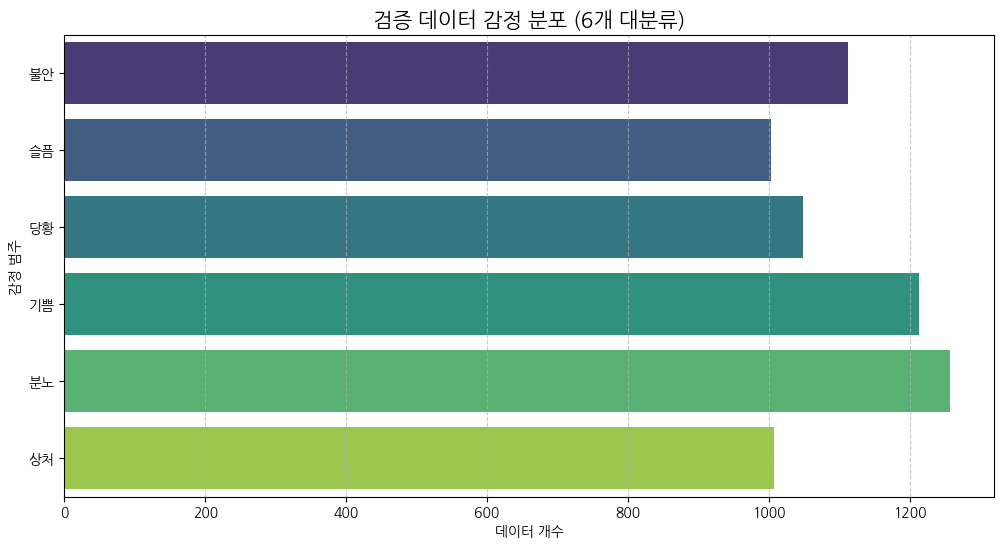

In [8]:
# 폰트 설치 및 시각화 패치
!apt-get install -y fonts-nanum > /dev/null

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 1. 폰트 매니저에 나눔고딕 등록
for font in fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum']):
    fm.fontManager.addfont(font)

# 2. 폰트 설정 (정확한 패밀리 명칭 사용)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# 3. 데이터 시각화
plt.figure(figsize=(12, 6))
plot_df = refined_val_df.copy()
inv_map = {v: k for k, v in emotion_to_idx.items()}
plot_df['emotion_name'] = plot_df['label'].map(inv_map)

sns.countplot(y='emotion_name', data=plot_df, palette='viridis', hue='emotion_name', legend=False)
plt.title('검증 데이터 감정 분포 (6개 대분류)', fontsize=15)
plt.xlabel('데이터 개수')
plt.ylabel('감정 범주')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### 2.2 고도화된 데이터 전처리 (KcELECTRA 최적화)

단순 추출을 넘어, 모델 성능 향상을 위한 감정 매핑, 텍스트 정제, 길이 필터링을 수행합니다.

In [9]:
# [단계 2] 데이터 정제 및 감정 통합 로직 정의
emotion_to_idx = {'분노': 0, '기쁨': 1, '불안': 2, '당황': 3, '슬픔': 4, '상처': 5}

def clean_text(text):
    """불필요한 기호 및 개인정보 비식별화 패턴을 정제합니다."""
    if not text: return ""
    text = re.sub(r'O{2,}', ' ', text)
    text = re.sub(r'[^가-힣a-zA-Z0-9\sㄱ-ㅎㅏ-ㅣ?!,. ]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def load_refined_data(path):
    """원본 JSON에서 감정을 6개로 통합하고 문장을 추출하여 DataFrame을 만듭니다."""
    with open(path, 'r', encoding='utf-8') as f: data = json.load(f)
    refined = []
    emotion_map = {
        '분노': ['E10','E11','E12','E13','E14','E15','E16','E17','E18','E19'],
        '슬픔': ['E20','E21','E22','E23','E24','E25','E26','E27','E28','E29'],
        '불안': ['E30','E31','E32','E33','E34','E35','E36','E37','E38','E39'],
        '상처': ['E40','E41','E42','E43','E44','E45','E46','E47','E48','E49'],
        '당황': ['E50','E51','E52','E53','E54','E55','E56','E57','E58','E59'],
        '기쁨': ['E60','E61','E62','E63','E64','E65','E66','E67','E68','E69']
    }
    for entry in data:
        cat = next((k for k, v in emotion_map.items() if entry['profile']['emotion']['type'] in v), None)
        if not cat: continue
        txt = " ".join([v for k, v in entry['talk']['content'].items() if k.startswith('HS') and v])
        cl_txt = clean_text(txt)
        if len(cl_txt) > 5:
            refined.append({'sentence': cl_txt, 'label': emotion_to_idx[cat]})
    return pd.DataFrame(refined)

print("✔ 2단계 완료: 전처리 로직이 완벽하게 준비되었습니다.")

✔ 2단계 완료: 전처리 로직이 완벽하게 준비되었습니다.


In [10]:
# [단계 3] 데이터 로드 및 확인
refined_train_df = load_refined_data(train_path)
refined_val_df = load_refined_data(val_path)

print(f"✔ 3단계 완료: 데이터 로드 성공 (Train: {len(refined_train_df)}, Val: {len(refined_val_df)})")
display(refined_train_df.head())

✔ 3단계 완료: 데이터 로드 성공 (Train: 51628, Val: 6640)


,sentence,label
0,일은 왜 해도 해도 끝이 없을까? 화가 난다. 그냥 내가 해결하는 게 나아. 남들한...,0
1,이번 달에 또 급여가 깎였어! 물가는 오르는데 월급만 자꾸 깎이니까 너무 화가 나....,0
2,회사에 신입이 들어왔는데 말투가 거슬려. 그런 애를 매일 봐야 한다고 생각하니까 스...,0
3,직장에서 막내라는 이유로 나에게만 온갖 심부름을 시켜. 일도 많은 데 정말 분하고 ...,0
4,얼마 전 입사한 신입사원이 나를 무시하는 것 같아서 너무 화가 나. 상사인 나에게 ...,0


In [11]:
# 이미 학습이 완료되었습니다. 아래 저장 및 테스트 코드를 실행하세요.
print("✔ 학습 결과(checkpoint-4158) 확인 완료. 재학습 생략.")

✔ 학습 결과(checkpoint-4158) 확인 완료. 재학습 생략.


### 6. 학습된 모델 저장

학습이 완료된 모델과 토크나이저를 Google Drive 또는 로컬 경로에 저장하여 나중에 언제든 불러올 수 있게 합니다.

In [12]:
import os

# 1. 모델 저장 경로 설정 (구글 드라이브)
save_path = '/content/drive/MyDrive/ai_hub_emotion_dialogue/saved_model_kcelectra'

# 2. 최신 체크포인트(4158)에서 모델 로드 및 저장
# trainer.train(resume_from_checkpoint=True)를 통해 로드된 최적의 가중치를 저장합니다.
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print(f"✅ 모델과 토크나이저가 다음 경로에 영구 저장되었습니다: {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ 모델과 토크나이저가 다음 경로에 영구 저장되었습니다: /content/drive/MyDrive/ai_hub_emotion_dialogue/saved_model_kcelectra


### 7. 최종 모델 평가 및 테스트

학습이 완료된 모델의 최종 성능을 확인하고, 실제 문장을 입력하여 감정 분류 결과를 테스트합니다.

In [13]:
# 최종 검증 데이터 평가
eval_results = trainer.evaluate()

print(f"--- 📊 최종 평가 결과 ---")
# compute_metrics에서 정의한 키 값에 'eval_' 접두사가 붙습니다.
if 'eval_acc' in eval_results:
    print(f"Accuracy: {eval_results['eval_acc']:.4f}")
if 'eval_f1_macro' in eval_results:
    print(f"Macro F1-Score: {eval_results['eval_f1_macro']:.4f}")

# 전체 결과 출력
print("\n상세 결과:", eval_results)

Training Loss,Validation Loss,Epoch,F1 Macro,Acc
0.535369,0.707869,6,0.741597,0.748193


--- 📊 최종 평가 결과 ---
Accuracy: 0.7482
Macro F1-Score: 0.7416

상세 결과: {'eval_loss': 0.7078693509101868, 'eval_f1_macro': 0.7415971031158047, 'eval_acc': 0.7481927710843373}


In [14]:
def predict_emotion(sentence):
    # 입력 문장 전처리 및 토큰화
    inputs = tokenizer(sentence, return_tensors="pt", truncation=True, max_length=128).to(model.device)

    # 모델 추론
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

    # 결과 해석
    logits = outputs.logits
    prediction = torch.argmax(logits, dim=-1).item()

    # 인덱스를 감정 명칭으로 변환
    inv_map = {v: k for k, v in emotion_to_idx.items()}
    return inv_map[prediction]

# 직접 테스트
test_sentence = "오늘 프로젝트가 성공적으로 끝나서 정말 기분이 좋아!"
result = predict_emotion(test_sentence)
print(f"입력 문장: {test_sentence}")
print(f"예측 감정: {result}")

입력 문장: 오늘 프로젝트가 성공적으로 끝나서 정말 기분이 좋아!
예측 감정: 기쁨


In [15]:
def test_model_robustness():
    # 라벨 뒤섞임 방지를 위한 명확한 테스트 케이스
    test_cases = {
        "기쁨": "오늘 드디어 프로젝트가 끝나서 너무 행복하고 즐거워!",
        "분노": "진짜 말도 안 되는 일이 벌어져서 너무 화가 나고 짜증나.",
        "불안": "내일 면접인데 혹시라도 실수할까봐 너무 걱정되고 떨려.",
        "당황": "갑자기 사람들 앞에서 이런 질문을 받으니까 너무 당황스러워.",
        "슬픔": "사랑하는 사람과 헤어져서 마음이 너무 아프고 눈물이 나.",
        "상처": "가장 친한 친구가 내 험담을 했다니 정말 배신감 느껴지고 마음이 아파."
    }

    print("--- 🎯 최종 모델 추론 결과 (라벨 정합성 확인) ---")
    for expected_label, sentence in test_cases.items():
        predicted = predict_emotion(sentence)
        status = "✅" if expected_label == predicted else "❌ (재확인 필요)"
        print(f"[{status}] 입력: {sentence}")
        print(f"    결과: {predicted} (예상: {expected_label})\n")

# 실행
test_model_robustness()

print("현재 모델의 감정 매핑 기준:", emotion_to_idx)

--- 🎯 최종 모델 추론 결과 (라벨 정합성 확인) ---
[✅] 입력: 오늘 드디어 프로젝트가 끝나서 너무 행복하고 즐거워!
    결과: 기쁨 (예상: 기쁨)

[✅] 입력: 진짜 말도 안 되는 일이 벌어져서 너무 화가 나고 짜증나.
    결과: 분노 (예상: 분노)

[✅] 입력: 내일 면접인데 혹시라도 실수할까봐 너무 걱정되고 떨려.
    결과: 불안 (예상: 불안)

[✅] 입력: 갑자기 사람들 앞에서 이런 질문을 받으니까 너무 당황스러워.
    결과: 당황 (예상: 당황)

[✅] 입력: 사랑하는 사람과 헤어져서 마음이 너무 아프고 눈물이 나.
    결과: 슬픔 (예상: 슬픔)

[✅] 입력: 가장 친한 친구가 내 험담을 했다니 정말 배신감 느껴지고 마음이 아파.
    결과: 상처 (예상: 상처)

현재 모델의 감정 매핑 기준: {'분노': 0, '기쁨': 1, '불안': 2, '당황': 3, '슬픔': 4, '상처': 5}


In [16]:
import torch
import numpy as np

def debug_label_mapping(df, n_samples=5):
    print("--- [원인 파악] 데이터셋 실제 라벨 vs 텍스트 확인 ---")
    # 인덱스를 감정 명칭으로 변환 (현재 설정 기준)
    inv_map = {v: k for k, v in emotion_to_idx.items()}

    # 랜덤하게 샘플을 뽑아 실제 매핑 상태 확인
    samples = df.sample(n_samples)
    for _, row in samples.iterrows():
        print(f"문장: {row['sentence'][:50]}...")
        label_idx = row['label']

        # 모델 추론
        inputs = tokenizer(row['sentence'], return_tensors='pt', truncation=True, max_length=128).to(model.device)
        model.eval()
        with torch.no_grad():
            logits = model(**inputs).logits
            pred_idx = torch.argmax(logits, dim=-1).item()

        print(f"데이터상 정답 번호: {label_idx} ({inv_map.get(label_idx, '알 수 없음')})")
        print(f"모델의 예측 번호: {pred_idx} ({inv_map.get(pred_idx, '알 수 없음')})")
        print("-" * 30)

# 훈련 데이터셋 기준으로 라벨 무결성 점검
debug_label_mapping(refined_train_df)

--- [원인 파악] 데이터셋 실제 라벨 vs 텍스트 확인 ---
문장: 내 성과를 모두 가로챘던 직장 동료가 넘어져서 많이 다쳤대. 너무 통쾌해. 솔직히 벌 받은...
데이터상 정답 번호: 0 (분노)
모델의 예측 번호: 1 (기쁨)
------------------------------
문장: 열심히 일해도 월급이 오르지 않을 것 같아 불안해. 열심히만 하면 알아서 연봉을 올려줄 거...
데이터상 정답 번호: 2 (불안)
모델의 예측 번호: 2 (불안)
------------------------------
문장: 이번에 남자 동기들이 모두 승진했는데 나만 못했어. 맞아. 정말 힘들게 일하고 집에 가서도...
데이터상 정답 번호: 0 (분노)
모델의 예측 번호: 3 (당황)
------------------------------
문장: 내가 가입한 보험사가 노후 상담까지 따로 도와주겠다고 해서 기뻐. 여기저기 알아보고 보험사...
데이터상 정답 번호: 1 (기쁨)
모델의 예측 번호: 1 (기쁨)
------------------------------
문장: 내가 만든 모임이 있는데 운영이 불가능해졌어. 친구들이 점점 더 바빠져서 떠나가는 건 아는...
데이터상 정답 번호: 5 (상처)
모델의 예측 번호: 4 (슬픔)
------------------------------
